## **Desenvolvimento do Pipeline de Pré-processamento e Arquitetura da Rede Neural**

Este notebook tem como objetivo desenvolver e avaliar os filtros de pré-processamento das imagens dos medidores, buscando melhorar características como nitidez e qualidade visual para facilitar as etapas posteriores de análise.

Após a definição dos filtros mais adequados, o notebook dará início à construção da arquitetura do modelo de visão computacional do projeto da Neoenergia. A arquitetura será responsável por processar as imagens dos medidores, extrair as informações relevantes e apoiar a classificação dos registros em situações como leitura confirmada, divergência ou impedimento/inconclusivo.

Dessa forma, o notebook representa uma etapa inicial do pipeline, partindo da melhoria e preparação das imagens até a definição da estrutura do modelo de inteligência artificial que será utilizado no fluxo de leitura e validação dos medidores.

- Configurações Iniciais

In [ ]:
# Importando bibliotecas necessárias
import cv2
import glob
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

sys.path.append(str(Path.cwd().parent))

from utils.image_convert import image2matrix
from image_preprocessing import ImageAnalyzer, Filter
from models.meter_identifier import MeterNetwork


pd.set_option('display.max_colwidth', None)

- Desenvolvimento de Pré-processamento das fotos

In [2]:
# Importando fotos para teste das classes de análise de imagem e aplicação de filtros
images = glob.glob("../data/meter_images/PSP_EXTRATLEITIMPL_030726_0121/*.jpg")

np.random.seed(42)
image = images[np.random.randint(0, len(images))]

In [3]:
# Analisando brilho e ruído da imagem
analyzer = ImageAnalyzer(images[10])
brilho = analyzer.get_brightness()
ruído = analyzer.get_noise()

print("Brilho:", brilho)
print("Status de brilho:", analyzer.brightness_status())

print("\nRuído:", ruído)
print("Status de ruído:", analyzer.noise_status())

Brilho: 7.437216435185185
Status de brilho: escura

Ruído: 7.4067592592592595
Status de ruído: borrada


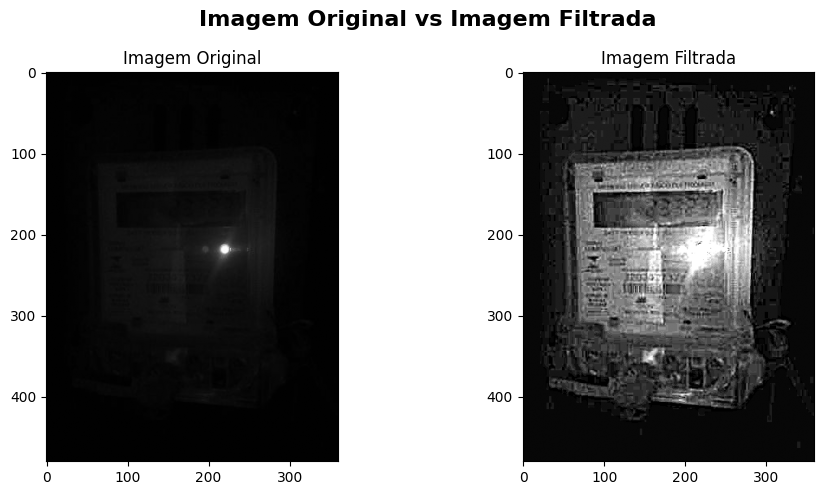

Evidência posição do medidor:


,Numero do medidor,Posicao do medidor lida,Nota de Leitura Atual,Foto do medidor
1525,3203427378,23323,NaN,PSP_EXTRATLEITIMPL_030726_0121_20000000000003010534_000.jpg


In [4]:
# Aplicando filtros
kernel = Filter(images[10])
analyzer = ImageAnalyzer(images[10])

image_filtered = kernel.sharpen(1.5)
image_filtered = kernel.increase_brightness(220)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plt.suptitle("Imagem Original vs Imagem Filtrada", fontsize=16, fontweight='bold')

axes[0].imshow(image2matrix(images[10]), cmap='gray')
axes[0].set_title("Imagem Original")

axes[1].imshow(image_filtered, cmap='gray')
axes[1].set_title("Imagem Filtrada")

plt.tight_layout()
plt.show()

sheets = pd.read_csv("../data/sheets/BaseExtracao_03072026_Dia.csv", sep=";")

print("Evidência posição do medidor:")
sheets[sheets["Posicao do medidor lida"] == 23323]


Os filtros `increase_brightness`, responsável por aumentar a luminosidade, e `sharpen`, utilizado para realçar a nitidez da imagem, apresentaram bons resultados. Na imagem original, não era possível identificar com clareza a posição registrada pelo medidor. Após a aplicação dos filtros, os dígitos passaram a apresentar maior definição e contraste, facilitando significativamente a visualização.

Esse resultado indica que uma etapa de pré-processamento e filtragem das imagens antes da entrada no modelo pode ser relevante para melhorar a qualidade das informações fornecidas à rede neural. Dessa forma, os filtros serão considerados na construção do pipeline, buscando fornecer ao modelo imagens com características mais adequadas para a identificação e leitura dos medidores.

O próximo passo será criar um modelo para identificação do medidor na foto.

- Modelo para identificação do medidor

In [5]:
# Transformando a imagem em um tensor
image_tensor = torch.from_numpy(image_filtered).float()

image_tensor = image_tensor.unsqueeze(0)
image_tensor = image_tensor.unsqueeze(0)

print(image_tensor.shape)

torch.Size([1, 1, 480, 360])


In [6]:
# Chamando modelo de rede neural criado
model = MeterNetwork()
output = model(image_tensor)

print(output.shape)

torch.Size([1, 5, 60, 45])
